In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("python_cleaned_data.csv")

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [4]:
df.shape

(9994, 21)

# Category Analysis

In [5]:
category_sales = df.groupby("Category")["Sales"].sum()

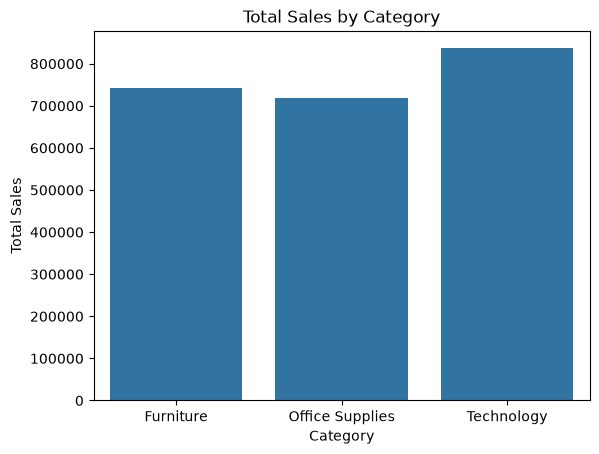

In [6]:
# Which category has the highest sales?
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Total Sales by Category")
#plt.xticks(rotation=45)
plt.show()

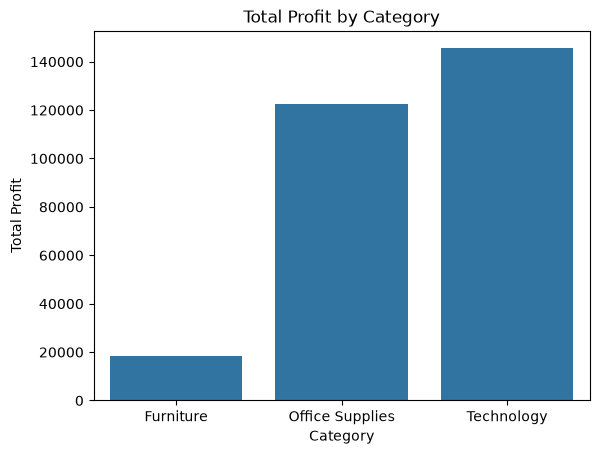

In [7]:
# Which category has the highest profit?
category_profit = df.groupby("Category")["Profit"].sum()
sns.barplot(x=category_profit.index, y=category_profit.values)
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.title("Total Profit by Category")
plt.show()


In [8]:
category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum()

category_analysis["Profit Margin"] = (
    category_analysis["Profit"] / category_analysis["Sales"]
).map("{:.2%}".format)

category_analysis

,Sales,Profit,Profit Margin
Category,,,
Furniture,741999.7953,18451.2728,2.49%
Office Supplies,719047.0320,122490.8008,17.04%
Technology,836154.0330,145454.9481,17.40%


### Category Performance

Technology generated the highest sales and also achieved a strong profit margin of approximately 17.39%. Office Supplies also maintained a strong profit margin of approximately 17.03%. In comparison, Furniture generated substantial sales but had a much lower profit margin of approximately 2.49%.

# Sub-category Analysis

In [9]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=True)
subcategory_sales

Sub-Category
Fasteners        3024.2800
Labels          12486.3120
Envelopes       16476.4020
Art             27118.7920
Supplies        46673.5380
Paper           78479.2060
Furnishings     91705.1640
Appliances     107532.1610
Bookcases      114879.9963
Copiers        149528.0300
Accessories    167380.3180
Machines       189238.6310
Binders        203412.7330
Tables         206965.5320
Storage        223843.6080
Chairs         328449.1030
Phones         330007.0540
Name: Sales, dtype: float64

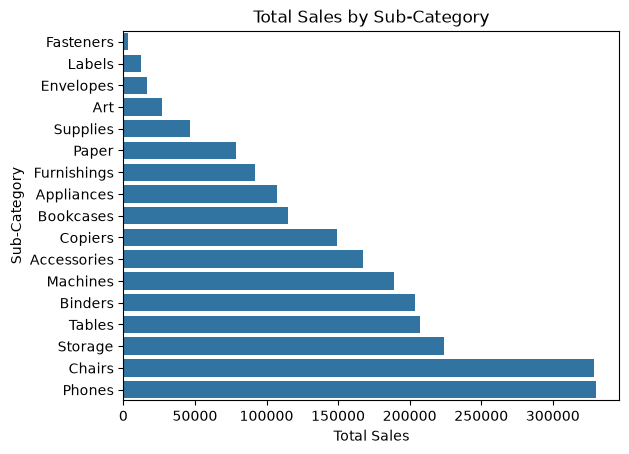

In [10]:
sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index
)

plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.title("Total Sales by Sub-Category")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

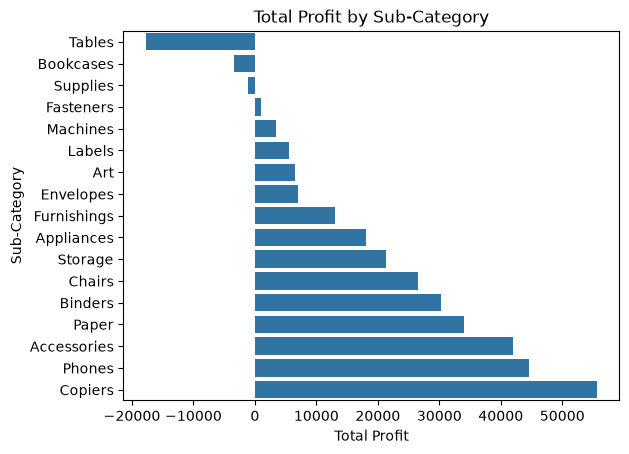

In [11]:
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=True)
subcategory_profit
sns.barplot(
    x=subcategory_profit.values,
    y=subcategory_profit.index
)

plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.title("Total Profit by Sub-Category")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

### Sub-Category Performance

Sales and profit differed considerably across sub-categories. Some sub-categories generated high sales while others contributed relatively low profit or losses.

Interpretation: High sales alone do not necessarily indicate strong business performance; sub-category profitability should also be considered when making product decisions.

# Regional Analysis


In [12]:
region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum()

region_analysis["Profit Margin"] = (
    region_analysis["Profit"] / region_analysis["Sales"]
).map("{:.2%}".format)

region_analysis

,Sales,Profit,Profit Margin
Region,,,
Central,501239.8908,39706.3625,7.92%
East,678781.2400,91522.7800,13.48%
South,391721.9050,46749.4303,11.93%
West,725457.8245,108418.4489,14.94%


In [13]:
# Which region has the highest sales?
region_sales=df.groupby("Region")["Sales"].sum()
region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

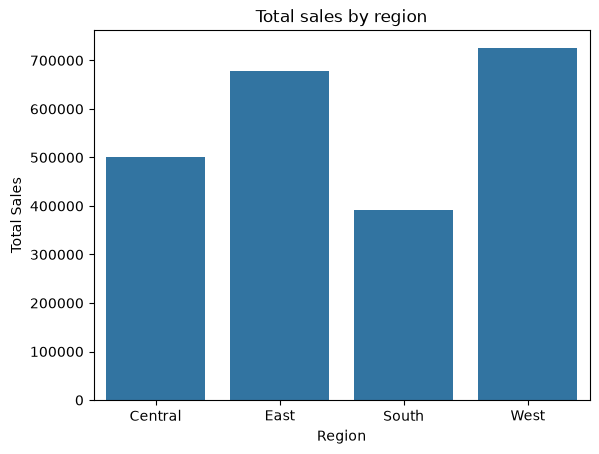

In [14]:
sns.barplot(x=region_sales.index,y=region_sales.values)
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Total sales by region")
plt.show()

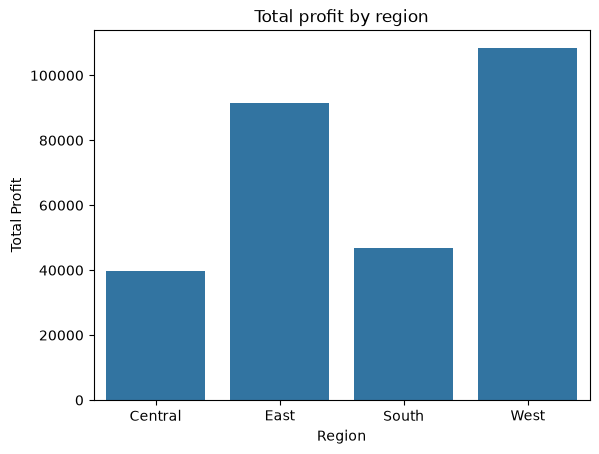

In [15]:
region_profit = df.groupby("Region")["Profit"].sum()
sns.barplot(x=region_profit.index,y=region_profit.values)
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.title("Total profit by region")
plt.show()


### Regional Performance

The West region generated the highest sales and profit, with a profit margin of approximately 15%. The Central region had the lowest profit margin at approximately 8%, despite generating significant sales.

Regional performance varies considerably, and the Central region may require further investigation into product mix, pricing, and discount patterns.

# Yearly Sales & Profit Trends

In [16]:
yearly_sales = df.groupby(df["Order Date"].dt.year)["Sales"].sum()
yearly_sales

Order Date
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

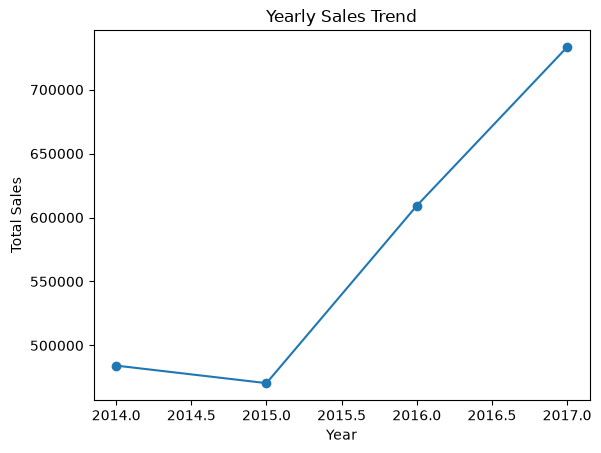

In [17]:
plt.plot(yearly_sales.index, yearly_sales.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Yearly Sales Trend")
plt.show()

# we used plt.plot() because for a simple time-series line chart, Matplotlib is perfectly suitable. We can use seaborn as well, but it is more commonly used for statistical visualizations and complex plots. For a straightforward line chart like this, Matplotlib is sufficient and provides more control over the plot's appearance.

In [18]:
yearly_profit = df.groupby(df["Order Date"].dt.year)["Profit"].sum()
yearly_profit

Order Date
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64

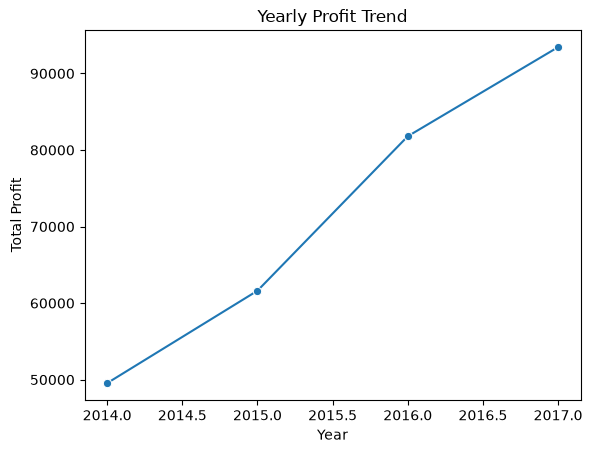

In [19]:
sns.lineplot(
    x=yearly_profit.index,
    y=yearly_profit.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Total Profit")
plt.title("Yearly Profit Trend")
plt.show()

### Yearly Sales Trend

Sales increased overall from 2014 to 2017, with the highest annual sales recorded in 2017 at approximately $733K. Profit also increased over the same period.

Interpretation: The business experienced overall growth during the four-year period, with 2017 showing the strongest annual performance.

# Customer Analysis

In [20]:
# New customers per year
#df.groupby("Customer ID")["Order Date"].min().dt.year
first_order_year = df.groupby("Customer ID")["Order Date"].min().dt.year
first_order_year.value_counts().sort_index()

Order Date
2014    595
2015    136
2016     51
2017     11
Name: count, dtype: int64

In [21]:
# Repeated customers
customer_orders =df.groupby("Customer ID")["Order ID"].nunique()
repeated_customers=customer_orders[customer_orders>1].count()
print("Total no. of repeated customers:",repeated_customers)
customer_orders[customer_orders > 1]



Total no. of repeated customers: 781


Customer ID
AA-10315     5
AA-10375     9
AA-10480     4
AA-10645     6
AB-10015     3
            ..
XP-21865    11
YC-21895     5
YS-21880     8
ZC-21910    13
ZD-21925     5
Name: Order ID, Length: 781, dtype: int64

In [22]:
# Average customer spend
average_spend= df["Sales"].sum()/df['Customer ID'].nunique()
print(f"Average Customer Spend: ${average_spend:,.2f}")

Average Customer Spend: $2,896.85


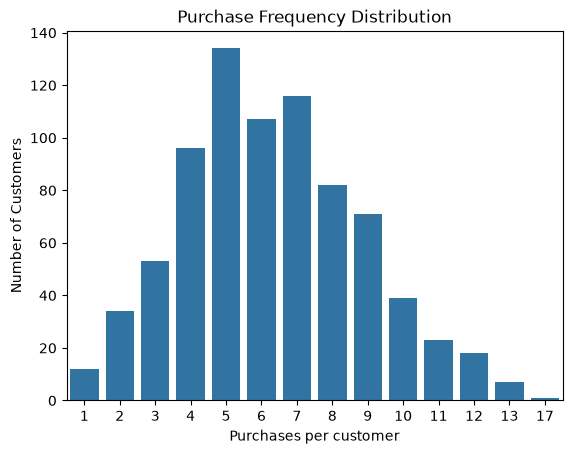

In [23]:
# Purchase Frequency
customer_orders =df.groupby("Customer ID")["Order ID"].nunique()
purchase_frequency = customer_orders.value_counts().sort_index()
sns.barplot(
    x=purchase_frequency.index,
    y=purchase_frequency.values
)

plt.xlabel("Purchases per customer")
plt.ylabel("Number of Customers")
plt.title("Purchase Frequency Distribution")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

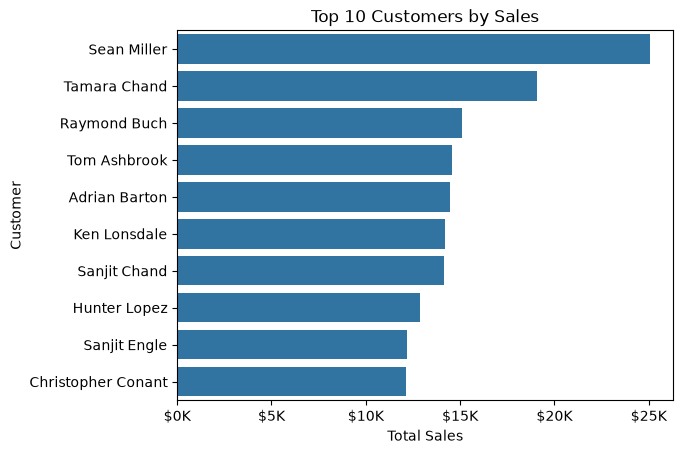

In [24]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.xlabel("Total Sales")
plt.ylabel("Customer")
plt.title("Top 10 Customers by Sales")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"${x/1e3:.0f}K")
)

plt.show()

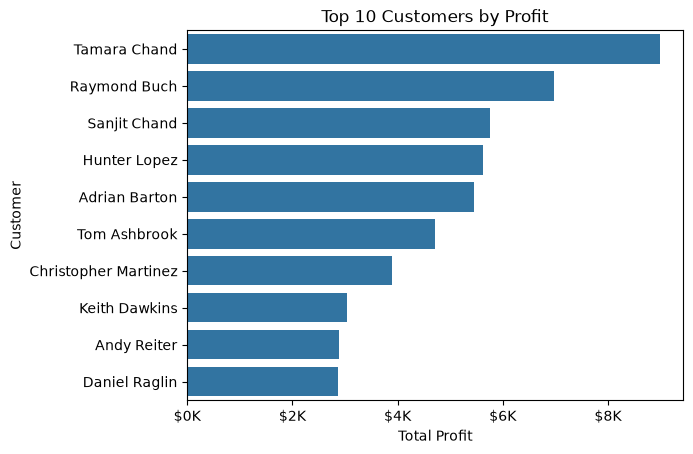

In [25]:
top_customers_profit = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
sns.barplot(
    x=top_customers_profit.values,
    y=top_customers_profit.index
)

plt.xlabel("Total Profit")
plt.ylabel("Customer")
plt.title("Top 10 Customers by Profit")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"${x/1e3:.0f}K")
)

plt.show()

### Customer Profitability

The customer analysis showed that some high-sales customers were highly profitable, while others generated relatively low profit or even losses. For example, Sean Miller had the highest sales among the listed top customers but recorded approximately -$1.98K profit.

Interpretation: Customer value should be evaluated using both revenue and profitability rather than sales alone.

In [26]:
segment_sales = df.groupby("Segment")["Sales"].sum()
segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

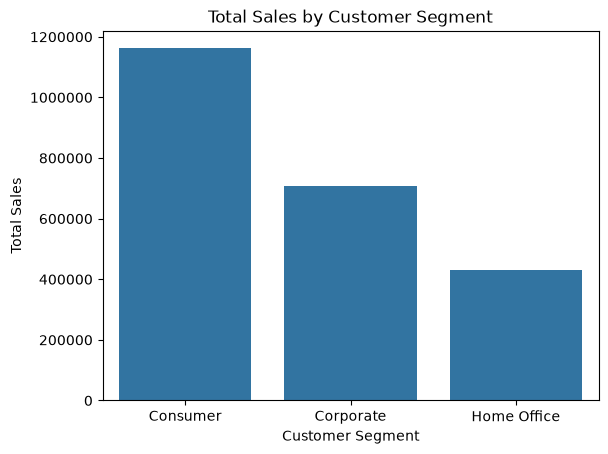

In [27]:
sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.title("Total Sales by Customer Segment")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

### Customer Segment Performance

Sales varied across the three customer segments, indicating that different customer groups contribute differently to overall revenue.

Segment-level analysis can help identify which customer groups contribute the most revenue and should be examined further for profitability and customer-value patterns.

# Discount Analysis

In [28]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .sum()
    .sort_index()
)
discount_profit

Discount
0.00    320987.6032
0.10      9029.1770
0.15      1418.9915
0.20     90337.3060
0.30    -10369.2774
0.32     -2391.1377
0.40    -23057.0504
0.45     -2493.1111
0.50    -20506.4281
0.60     -5944.6552
0.70    -40075.3569
0.80    -30539.0392
Name: Profit, dtype: float64

### Discount and Profit Relationship

The analysis showed that higher discount levels were generally associated with lower profitability. Several high-discount levels, particularly 30% and above, showed negative aggregated profit.

The relationship suggests that heavy discounting can be associated with weaker profitability in this dataset. However, correlation or association alone does not establish that discounts directly caused the losses.

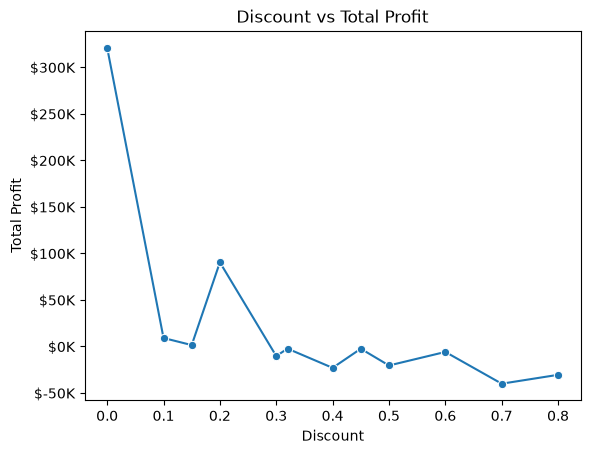

In [29]:
sns.lineplot(
    x=discount_profit.index,
    y=discount_profit.values,
    marker="o"
)

plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.title("Discount vs Total Profit")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"${x/1e3:.0f}K")
)

plt.show()

# Product Analysis

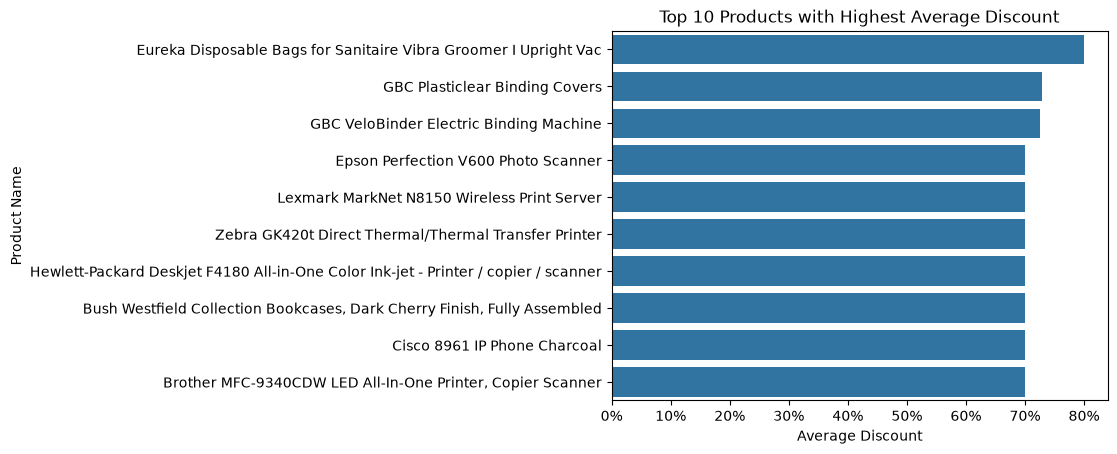

In [30]:
# Which products receive the highest average discount?
product_discount= df.groupby("Product Name")["Discount"].mean().sort_values(ascending=False).head(10)
sns.barplot(
    x=product_discount.values,
    y=product_discount.index
)

plt.xlabel("Average Discount")
plt.ylabel("Product Name")
plt.title("Top 10 Products with Highest Average Discount")
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x:.0%}")
)
plt.show()


In [31]:
# Top 10 products by sales
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [32]:
# Top 10 products by profit
top_products_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_profit

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

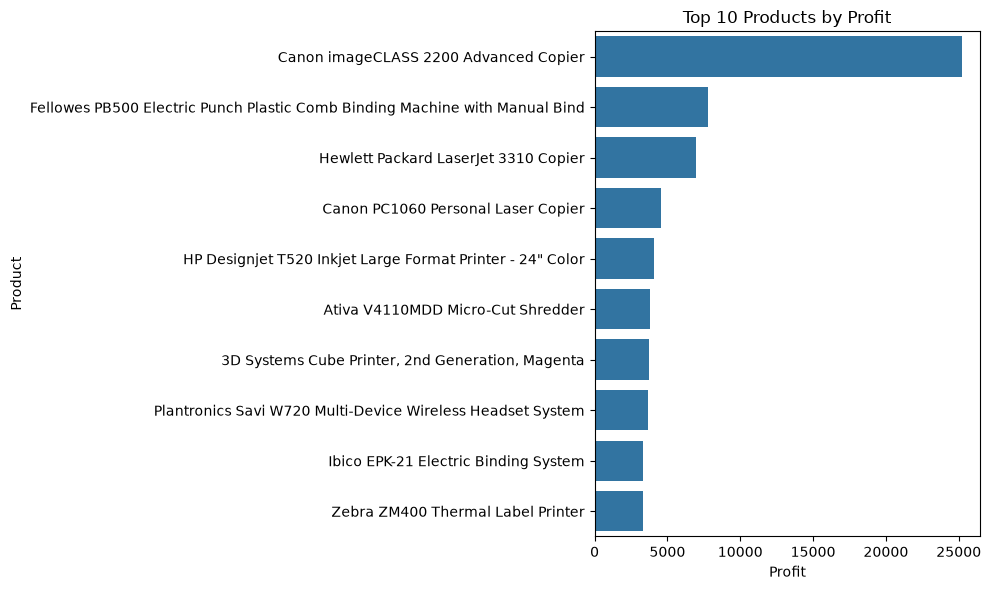

In [35]:

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products_profit.values, y=top_products_profit.index)
plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

Best-selling products are not necessarily the most profitable products. Although some products such as the Canon imageCLASS 2200 Advanced Copier perform strongly in both sales and profit, other products generate relatively high sales but low or negative profit. Therefore, product performance should be evaluated using both sales and profitability rather than sales alone.

In [36]:
# loss making products
loss_making_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
)
loss_making_products 

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

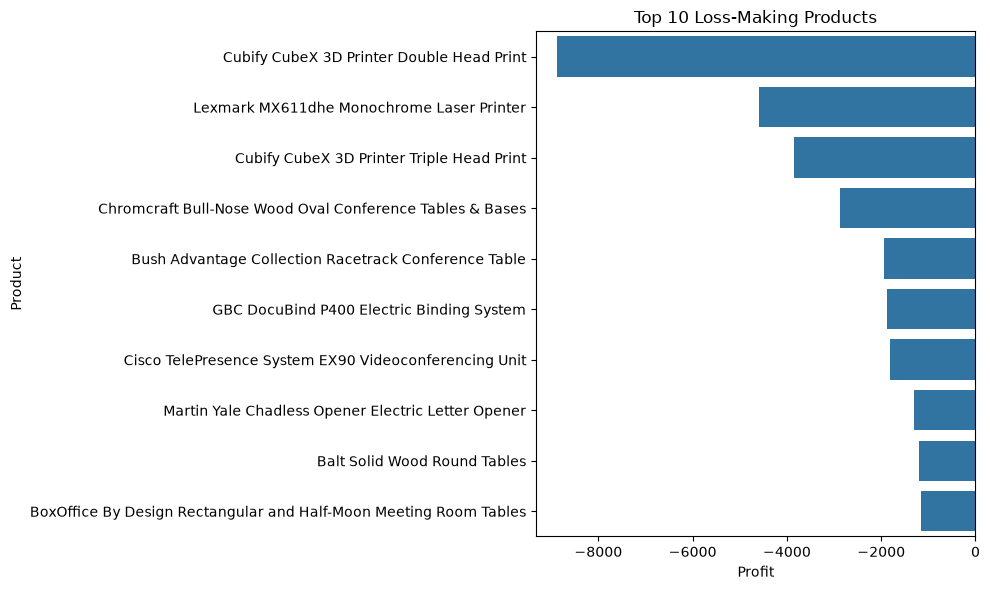

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(x=loss_making_products.values, y=loss_making_products.index)
plt.title("Top 10 Loss-Making Products")
plt.xlabel("Profit")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# Statistical Analysis

In [ ]:
df[["Sales", "Profit", "Quantity", "Discount"]].describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


1. The median sales value is $54.49, meaning half of the sales records have sales below or equal to this value. The mean sales value is $229.86, which is substantially higher than the median, indicating that high-value sales records are pulling the average upward.

2. The median profit is $8.67, meaning half of the sales records generate profit of $8.67 or less, while the other half generate $8.67 or more. The mean profit of $28.66 is considerably higher, indicating that some high-profit records increase the average.

3. Standard Deviation
- Sales have a standard deviation of approximately $623.25, indicating substantial variation in sales values across records.

- Profit has a standard deviation of approximately $234.26, indicating considerable variation in profit across sales records.

- Quantity has a standard deviation of 2.23 units, indicating relatively smaller variation compared with sales and profit.

- Discount has a standard deviation of approximately 20.65 percentage points, indicating considerable variation in discount levels.

4. 25% of sales records have sales of $17.28 or less, 50% have sales of $54.49 or less, and 75% have sales of $209.94 or less.

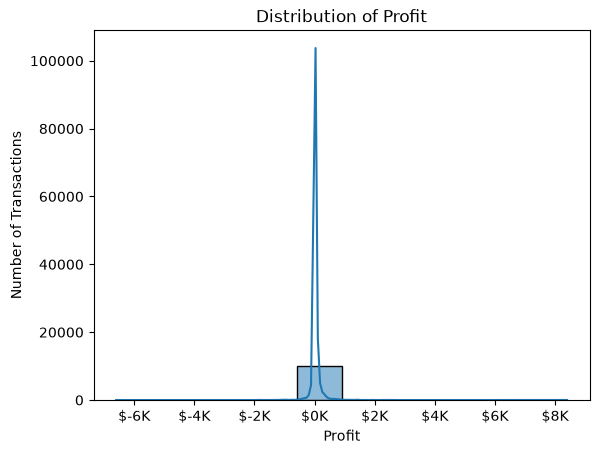

In [ ]:
#Profit Distribution
sns.histplot(
    df["Profit"],
    bins=10,
    kde=True
)

plt.xlabel("Profit")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Profit")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"${x/1e3:.0f}K")
)

plt.show()

### Profit Distribution

The profit distribution showed that most transactions are concentrated around relatively smaller profit values, while a smaller number of transactions have very high positive or negative profit.

Interpretation: Profitability is uneven across individual transactions, with some transactions contributing disproportionately to overall profit or loss.

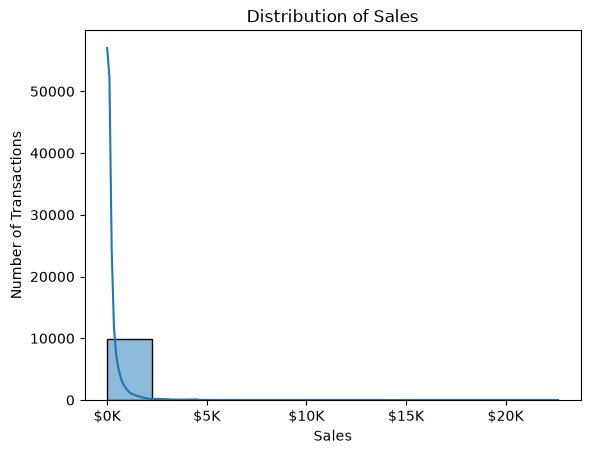

In [ ]:
#Sales Distribution
sns.histplot(
    df["Sales"],
    bins=10,
    kde=True
)

plt.xlabel("Sales")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Sales")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"${x/1e3:.0f}K")
)

plt.show()

### Sales Distribution

The sales distribution showed that most individual sales records have relatively lower sales values, while a smaller number of records have much higher sales values.

Interpretation: Sales are not evenly distributed across transactions, and a limited number of high-value transactions contribute significantly to total revenue.

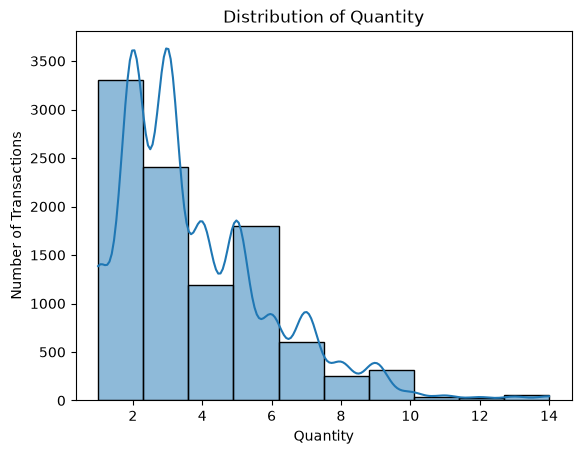

In [ ]:
#Quantity Distribution
sns.histplot(
    df["Quantity"],
    bins=10,
    kde=True
)

plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Quantity")

plt.show()

### Quantity Distribution:
The quantity distribution shows how frequently different quantities of products are sold in individual sales records. Most transactions contain relatively small quantities, while transactions with higher quantities occur less frequently. This indicates that the dataset is primarily composed of low-quantity transactions.

### Discount vs Sales

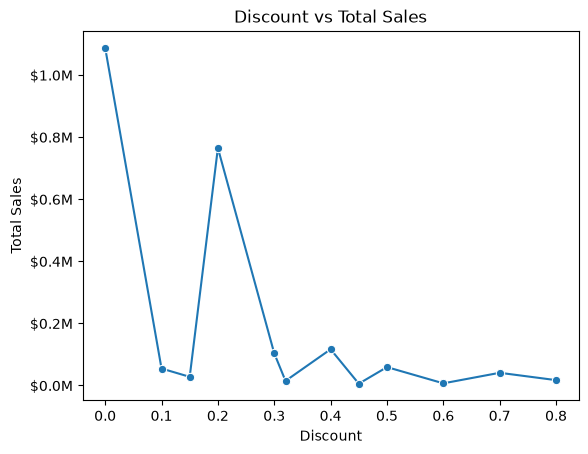

In [ ]:
discount_sales = df.groupby("Discount")["Sales"].sum().sort_index()

sns.lineplot(
    x=discount_sales.index,
    y=discount_sales.values,
    marker="o"
)

plt.xlabel("Discount")
plt.ylabel("Total Sales")
plt.title("Discount vs Total Sales")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"${x/1e6:.1f}M")
)

plt.show()

Sales vary across discount levels, but higher discounts do not consistently correspond to higher total sales. The highest sales are associated with 0% and 20% discount levels, while several higher discount levels contribute considerably less sales.

### Correlation Analysis

<Axes: >

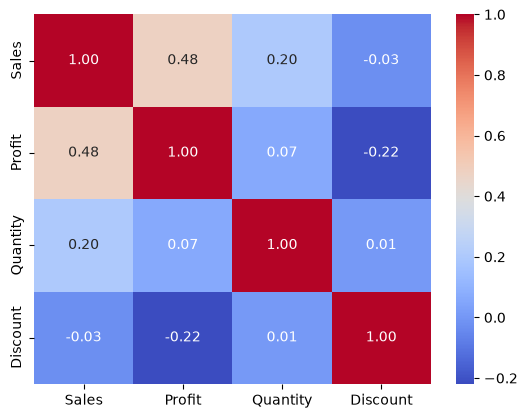

In [ ]:
#Correlation Analysis
corr_matrix = df[["Sales", "Profit", "Quantity", "Discount"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

### Sales and Profit Correlation

The correlation analysis showed a strong positive relationship between Sales and Profit.

Interpretation: Higher sales values are generally associated with higher profit values in the dataset, although the relationship does not imply that increasing sales alone will always increase profitability.

### Quantity and Sales correlation
Quantity and Sales had a weak positive correlation of approximately 0.20.

Interpretation: The number of units in a transaction has only a limited linear relationship with sales. Factors such as product price and product mix also contribute to sales value.

### Discount and Profit Correlation

The correlation analysis showed a negative relationship between Discount and Profit.

Interpretation: Higher discounts tend to be associated with lower profit in the dataset. This supports further investigation of discount policies and their impact on margins.


# Summary

In [ ]:
#Summary Dataframe

AOV = df["Sales"].sum() / df["Order ID"].nunique()
Profit_margin = df["Profit"].sum() / df["Sales"].sum()

summary_df =pd.DataFrame({
    "Total Sales": [df["Sales"].sum()],
    "Total Orders": [df["Order ID"].nunique()],
    "Total Customers": [df["Customer ID"].nunique()],
    "Total Profit": [df["Profit"].sum()],
    "Average Order Value": [AOV],
    "Profit Margin": [Profit_margin]
})

summary_df["Total Sales"] = summary_df["Total Sales"].map("${:,.2f}".format)
summary_df["Total Profit"] = summary_df["Total Profit"].map("${:,.2f}".format)
summary_df["Average Order Value"] = summary_df["Average Order Value"].map("${:,.2f}".format)
summary_df["Profit Margin"] = summary_df["Profit Margin"].map("{:.2%}".format)


summary_df

,Total Sales,Total Orders,Total Customers,Total Profit,Average Order Value,Profit Margin
0,"$2,297,200.86",5009,793,"$286,397.02",$458.61,12.47%


### Key Findings
1. Overall Performance: The business generated approximately $2.30M in sales and $286.40K in profit, with an overall profit margin of 12.47%.
2. Category Performance: Technology generated the highest sales (~$836K) and a strong profit margin of 17.40%, while Furniture had a much lower margin of 2.49%.
3. Regional Performance: West generated the highest sales (~$725K) and profit margin (14.94%), while Central had the lowest regional margin (7.92%).
4. Product Profitability: The best-selling product was also among the most profitable, but some high-sales products generated low or negative profit. Therefore, sales alone should not be used to evaluate product performance.
5. Loss-Making Products: The Cubify CubeX 3D Printer Double Head Print generated the largest product-level loss of approximately $8.88K.
6. Customer Retention: 781 of 793 customers were repeat customers, indicating that most customers placed more than one order.
7. Customer Spend: Average customer spend was approximately $2,896.85.
8. Discounts: Higher discount levels were generally associated with lower profitability, with several 30%+ discount levels producing negative aggregate profit.
9. Sales Distribution: Mean sales ($229.86) were considerably higher than median sales ($54.49), indicating that high-value records influence the average.
10. Correlation: Sales and Profit showed a strong positive relationship, while Quantity and Sales showed only a weak positive relationship.

### Overall EDA Conclusion

The exploratory analysis provides a detailed view of sales, profitability, customers, products, regions, and discount patterns. The results show that sales growth does not always translate into proportional profitability. Category, regional, product, customer, and discount-level differences highlight areas requiring further business evaluation. In particular, low-margin product categories, loss-making products, regional margin differences, and high discount levels should be examined when developing business strategies.